In [2]:
import netket as nk
from netket.graph import Lattice
import numpy as np
import math
import matplotlib.pyplot as plt
import json

/Users/tfc/code/mb-psi-net/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3
[[0 0 0]
 [0 0 1]
 [0 0 2]]
[[1. 0.]
 [0. 1.]
 [1. 1.]]


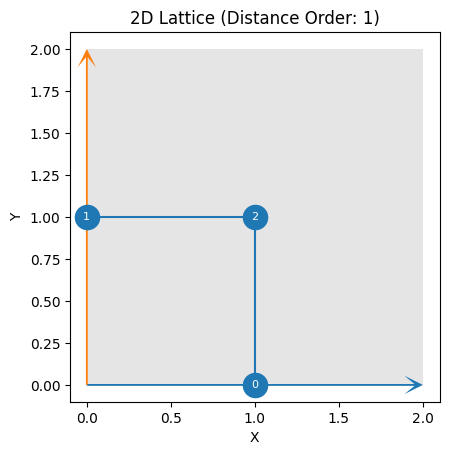

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [9]:
# Hexagonal lattice basis
sqrt3 = np.sqrt(3.0)
basis = np.array([
    [2.0, 0.0],
    [0.0, 2.0],
    #[0.5, sqrt3 / 2.0],
])
# Kagome unit cell
cell = np.array([
    basis[0] / 2.0,
    basis[1] / 2.0,
    (basis[0]+basis[1])/2.0
])
g = Lattice(basis_vectors=basis, site_offsets=cell, extent=[1, 1], pbc=False)
print(g.n_nodes)
print(g.basis_coords)

print(g.positions)

g.draw()

Nodes of a 24-edge regular polygon with radius 2.0 and center (1.0, 1.0):
Node 1: (4.0000, 2.0000)
Node 2: (3.9319, 2.5176)
Node 3: (3.7321, 3.0000)
Node 4: (3.4142, 3.4142)
Node 5: (3.0000, 3.7321)
Node 6: (2.5176, 3.9319)
Node 7: (2.0000, 4.0000)
Node 8: (1.4824, 3.9319)
Node 9: (1.0000, 3.7321)
Node 10: (0.5858, 3.4142)
Node 11: (0.2679, 3.0000)
Node 12: (0.0681, 2.5176)
Node 13: (0.0000, 2.0000)
Node 14: (0.0681, 1.4824)
Node 15: (0.2679, 1.0000)
Node 16: (0.5858, 0.5858)
Node 17: (1.0000, 0.2679)
Node 18: (1.4824, 0.0681)
Node 19: (2.0000, 0.0000)
Node 20: (2.5176, 0.0681)
Node 21: (3.0000, 0.2679)
Node 22: (3.4142, 0.5858)
Node 23: (3.7321, 1.0000)
Node 24: (3.9319, 1.4824)
24
[[ 0  0  0]
 [ 0  0  1]
 [ 0  0  2]
 [ 0  0  3]
 [ 0  0  4]
 [ 0  0  5]
 [ 0  0  6]
 [ 0  0  7]
 [ 0  0  8]
 [ 0  0  9]
 [ 0  0 10]
 [ 0  0 11]
 [ 0  0 12]
 [ 0  0 13]
 [ 0  0 14]
 [ 0  0 15]
 [ 0  0 16]
 [ 0  0 17]
 [ 0  0 18]
 [ 0  0 19]
 [ 0  0 20]
 [ 0  0 21]
 [ 0  0 22]
 [ 0  0 23]]
[[4.         2.    

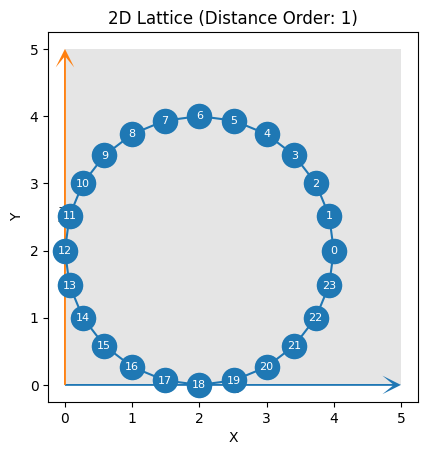

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [21]:
def get_regular_polygon_nodes(num_edges: int, radius: float = 1.0, center: tuple = (0, 0)):
    """
    Calculates the coordinates of the vertices (nodes) of a regular polygon.

    Args:
        num_edges (int): The number of edges (and vertices) of the polygon.
                         Must be an integer greater than or equal to 3.
        radius (float): The radius of the circumcircle on which the vertices lie.

    Returns:
        list: A list of tuples, where each tuple (x, y) represents the
              coordinates of a vertex.
    """
    if num_edges < 3:
        print("A polygon must have at least 3 edges.")
        return []

    nodes = np.empty((num_edges, 2), dtype=float)
    # Calculate the angle between successive vertices
    angle_increment = 2 * math.pi / num_edges

    for i in range(num_edges):
        # Calculate the angle for the current vertex
        angle = i * angle_increment
        # Calculate x and y coordinates
        x = radius * math.cos(angle) + center[0]
        y = radius * math.sin(angle) + center[1]
        nodes[i] = (x, y)
    return nodes

# Define the number of edges for the polygon
num_edges = 24
# Define the radius of the circumcircle (can be changed as needed)
polygon_radius = 2.0

center = (polygon_radius/2,polygon_radius/2)  # Center of the polygon, can be adjusted as needed

# Get the nodes
twenty_four_gon_nodes = get_regular_polygon_nodes(num_edges, polygon_radius, center)

twenty_four_gon_nodes = np.array(twenty_four_gon_nodes)
twenty_four_gon_nodes += np.array([1.0, 1.0])  # Shift the polygon to center it at (1, 1)

print(f"Nodes of a {num_edges}-edge regular polygon with radius {polygon_radius} and center ({center[0]}, {center[1]}):")
for i, node in enumerate(twenty_four_gon_nodes):
    print(f"Node {i+1}: ({node[0]:.4f}, {node[1]:.4f})")

basis = np.array([
    [5.0, 0.0],
    [0.0, 5.0],
])

# 
cell = twenty_four_gon_nodes

g = Lattice(basis_vectors=basis, site_offsets=cell, extent=[1, 1], pbc=False)
print(g.n_nodes)
print(g.basis_coords)

print(g.positions)

g.draw()
